Things to explore:
- two loss functions (add softmax and loss each timepoint)
- synaptic decay heterogeneity (initialization)
- learnable parameters

- maybe later test with synapses and alif

Test for each combination

In [1]:
import torch

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

c:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

130864128it [00:17, 7468174.54it/s]                               


Extracting C:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\datasets\data\SHD\shd_train.h5.zip to C:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\datasets\data\SHD


38141952it [00:01, 30177497.57it/s]                              


Extracting C:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\datasets\data\SHD\shd_test.h5.zip to C:\Users\Emiel\Documents\Study\AI_x_CNS\Thesis\Thesis-Code\datasets\data\SHD


Test Accuracy before training is: 0.04871323529411765


Epoch 0:   2%|▏         | 1/63 [00:01<01:27,  1.41s/it, acc=1.56%, loss=3.00]

Epoch 0, Iteration 0 — Loss: 3.00, Acc: 1.56%


Epoch 0:  41%|████▏     | 26/63 [00:20<00:27,  1.35it/s, acc=5.47%, loss=3.08] 

Epoch 0, Iteration 25 — Loss: 3.08, Acc: 5.47%


...

Epoch 9, Iteration 25 — Loss: 3.08, Acc: 4.69%


Epoch 9:  81%|████████  | 51/63 [00:14<00:03,  3.47it/s, acc=8.59%, loss=3.04] 

Epoch 9, Iteration 50 — Loss: 3.04, Acc: 8.59%


Epoch 9: 100%|██████████| 63/63 [00:17<00:00,  3.62it/s, acc=7.03%, loss=3.04]


Test Accuracy after training is: 0.06847426470588236


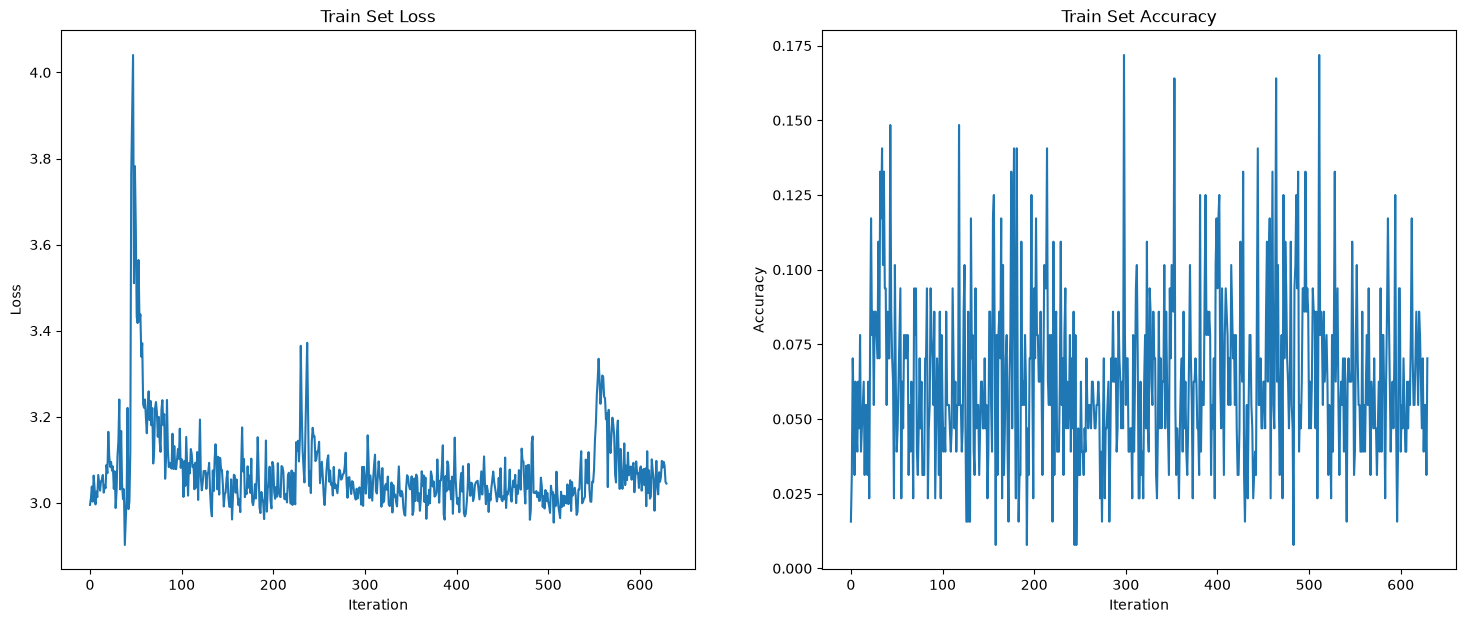

In [6]:
# Normal loss

import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.042279411764705885


Epoch 0:   2%|▏         | 1/63 [00:00<00:23,  2.61it/s, acc=20.31%, loss=2.92]

Epoch 0, Iteration 0 — Loss: 2.92, Acc: 20.31%


Epoch 0:  41%|████▏     | 26/63 [00:09<00:14,  2.59it/s, acc=21.09%, loss=2.88]

Epoch 0, Iteration 25 — Loss: 2.88, Acc: 21.09%


...

Epoch 49, Iteration 25 — Loss: 2.53, Acc: 85.16%


Epoch 49:  81%|████████  | 51/63 [00:19<00:04,  2.58it/s, acc=75.78%, loss=2.65]

Epoch 49, Iteration 50 — Loss: 2.65, Acc: 75.78%


Epoch 49: 100%|██████████| 63/63 [00:24<00:00,  2.62it/s, acc=89.06%, loss=2.51]


Test Accuracy after training is: 0.3561580882352941


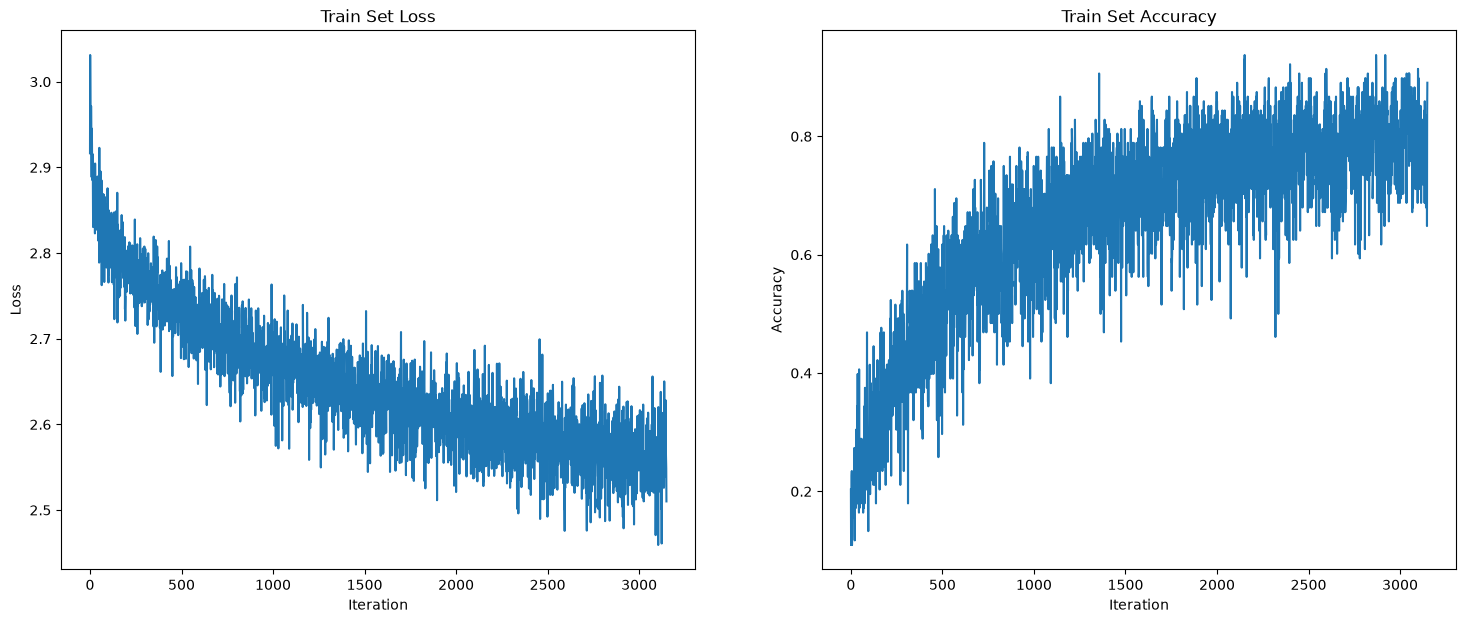

In [12]:
# Loss at each timepoint independently

import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import Tensor
import snntorch as snn
from snntorch import utils

class SimpleSRNNAdaptedForward(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out, bias=False))
            modules.append(snn.RLeaky(beta=beta, linear_features=_n_out, init_hidden=True))

        modules.append(nn.Linear(ns_hidden[-1], n_out, bias=False))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        return self.net(x)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_out, targets):
    return loss_fn(mem_out, targets).mean()

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec = [], []
            utils.reset(net)
            num_steps = data.size(0)
            for step in range(num_steps):
                spk_out, mem_out = net(data[step])
                spk_rec.append(spk_out)
                mem_rec.append(mem_out)

            spk_rec = torch.stack(spk_rec, dim=0)
            mem_rec = torch.stack(mem_rec, dim=0)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def forward_backward(net: nn.Module, optimizer, data: Tensor, targets: Tensor) -> tuple[Tensor, Tensor, float]:
    spk_rec, mem_rec = [], []
    avg_loss = 0

    num_steps = data.size(0)
    for step in range(num_steps):
        utils.reset(net.net)
        spk_out, mem_out = net(data[step])
        spk_rec.append(spk_out)
        mem_rec.append(mem_out)

        loss_val = compute_loss(mem_rec[-1], targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        snn.RLeaky.detach_hidden()
        snn.Leaky.detach_hidden()

        avg_loss += loss_val.item()

    return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0), avg_loss / num_steps

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec, avg_loss = forward_backward(net, optimizer, data, targets)
            loss_hist.append(avg_loss)

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{avg_loss:.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {avg_loss:.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNAdaptedForward(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=50,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.05284926470588235


Epoch 0:   2%|▏         | 1/63 [00:09<09:19,  9.02s/it, acc=3.91%, loss=2.85]

Epoch 0, Iteration 0 — Loss: 2.85, Acc: 3.91%


Epoch 0:  41%|████▏     | 26/63 [04:04<05:39,  9.19s/it, acc=10.16%, loss=2.87]

Epoch 0, Iteration 25 — Loss: 2.87, Acc: 10.16%


...

Epoch 9, Iteration 25 — Loss: 2.72, Acc: 8.59%


Epoch 9:  81%|████████  | 51/63 [05:56<01:19,  6.64s/it, acc=12.50%, loss=2.87]

Epoch 9, Iteration 50 — Loss: 2.87, Acc: 12.50%


Epoch 9: 100%|██████████| 63/63 [07:19<00:00,  6.97s/it, acc=7.03%, loss=3.05] 


Test Accuracy after training is: 0.06204044117647059


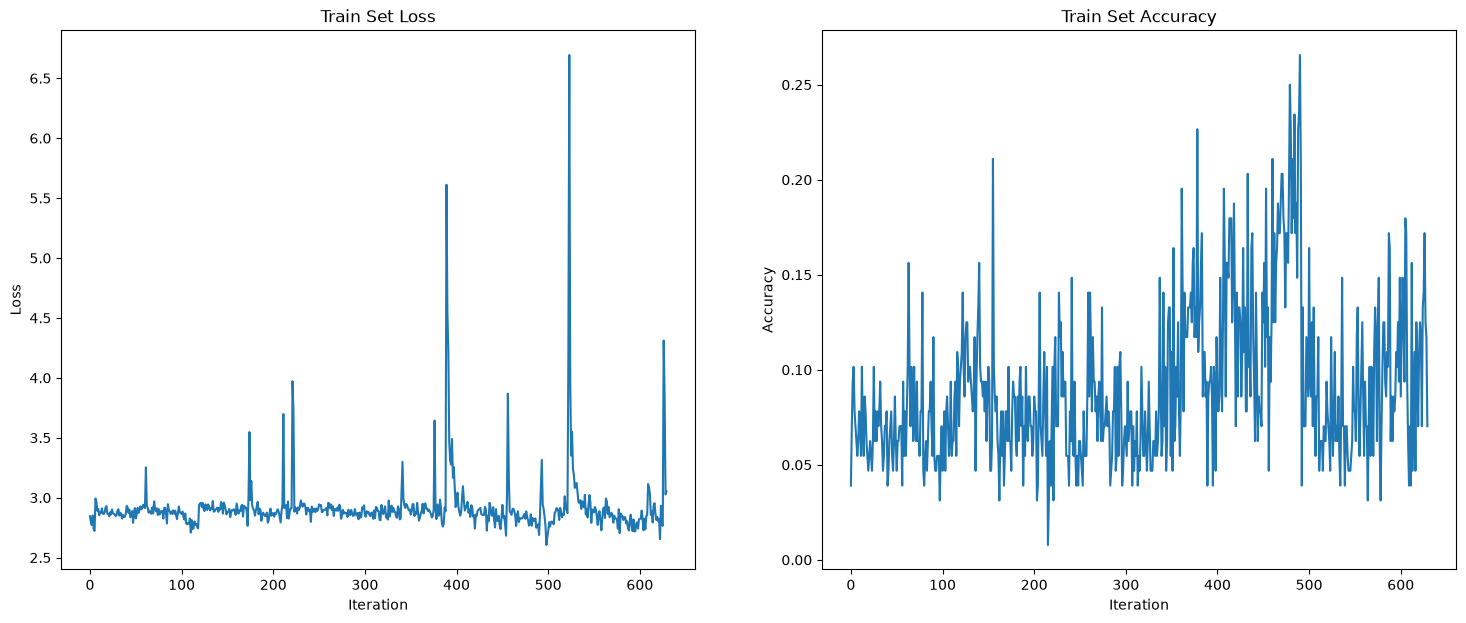

In [7]:
# Loss each timepoint, ensure that for timepoint t, it also computes from all prior timepoints t - n

import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import Tensor
import snntorch as snn
from snntorch import utils

class SimpleSRNNAdaptedForward(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out))
            modules.append(snn.RLeaky(beta=beta, linear_features=_n_out, init_hidden=True))

        modules.append(nn.Linear(ns_hidden[-1], n_out))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        return self.net(x)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_out, targets):
    return loss_fn(mem_out, targets).mean()

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec = [], []
            utils.reset(net)
            num_steps = data.size(0)
            for step in range(num_steps):
                spk_out, mem_out = net(data[step])
                spk_rec.append(spk_out)
                mem_rec.append(mem_out)

            spk_rec = torch.stack(spk_rec, dim=0)
            mem_rec = torch.stack(mem_rec, dim=0)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def forward_backward(net: nn.Module, optimizer, data: Tensor, targets: Tensor) -> tuple[Tensor, Tensor, float]:
    """
    Backwards loss for each individual timestep.
    Ensures that each output still depends on all prior timepoints.
    This means a double loop, for each output_timepoint, and for each timepoint before this output_timepoint.
    Hopefully this will bias updates towards the recurrent layers.
    """
    spk_rec, mem_rec = [], []
    avg_loss = 0

    total_num_steps = data.size(0)
    for num_steps in range(1, total_num_steps + 1):
        spk_rec, mem_rec = [], []   # only take final iteration as outputs

        utils.reset(net.net)
        for step in range(num_steps):
            spk_out, mem_out = net(data[step])
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        loss_val = compute_loss(mem_rec[-1], targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        avg_loss += loss_val.item()

    return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0), avg_loss / total_num_steps

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec, avg_loss = forward_backward(net, optimizer, data, targets)
            loss_hist.append(avg_loss)

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{avg_loss:.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {avg_loss:.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNAdaptedForward(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.04090073529411765


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]C:\Users\emiel\AppData\Local\Temp\ipykernel_48184\2877129191.py:14: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  loss_val += loss_fn(softmax(mem_out), targets).mean() / len(mem_rec)
Epoch 0:   2%|▏         | 1/63 [00:00<00:29,  2.09it/s, acc=7.03%, loss=3.00]

Epoch 0, Iteration 0 — Loss: 3.00, Acc: 7.03%


Epoch 0:  41%|████▏     | 26/63 [00:14<00:19,  1.88it/s, acc=5.47%, loss=2.99]

Epoch 0, Iteration 25 — Loss: 2.99, Acc: 5.47%


...

Epoch 9, Iteration 25 — Loss: 3.03, Acc: 3.12%


Epoch 9:  81%|████████  | 51/63 [00:30<00:06,  1.72it/s, acc=3.12%, loss=3.02] 

Epoch 9, Iteration 50 — Loss: 3.02, Acc: 3.12%


Epoch 9: 100%|██████████| 63/63 [00:37<00:00,  1.66it/s, acc=10.16%, loss=2.99]


Test Accuracy after training is: 0.05514705882352941


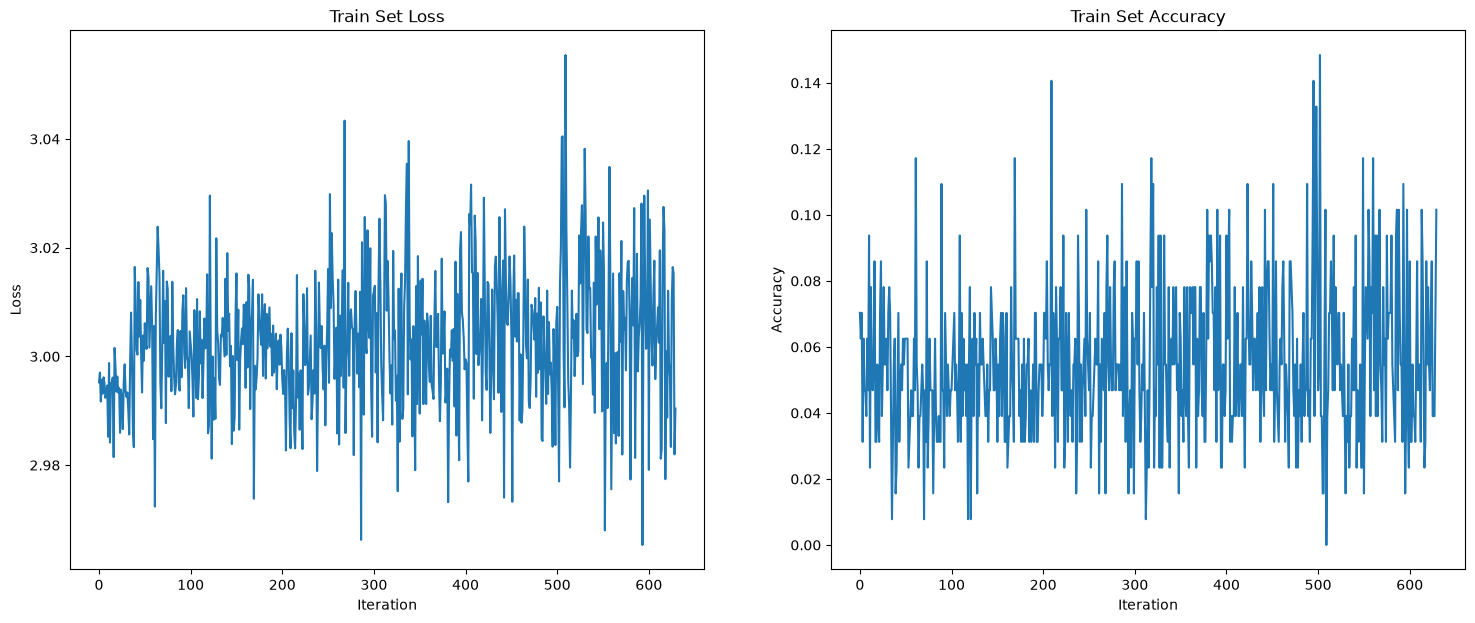

In [10]:
# Softmax loss

import torch.nn as nn
from torch.nn.functional import softmax
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(softmax(mem_out), targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.051470588235294115


Epoch 0:   2%|▏         | 1/63 [00:00<00:33,  1.88it/s, acc=6.25%, loss=3.03]

Epoch 0, Iteration 0 — Loss: 3.03, Acc: 6.25%


Epoch 0:  41%|████▏     | 26/63 [00:13<00:17,  2.08it/s, acc=10.94%, loss=3.27]

Epoch 0, Iteration 25 — Loss: 3.27, Acc: 10.94%


...

Epoch 9, Iteration 25 — Loss: 3.21, Acc: 5.47%


Epoch 9:  81%|████████  | 51/63 [00:29<00:07,  1.65it/s, acc=3.91%, loss=3.05] 

Epoch 9, Iteration 50 — Loss: 3.05, Acc: 3.91%


Epoch 9: 100%|██████████| 63/63 [00:35<00:00,  1.77it/s, acc=4.69%, loss=3.05] 


Test Accuracy after training is: 0.05330882352941176


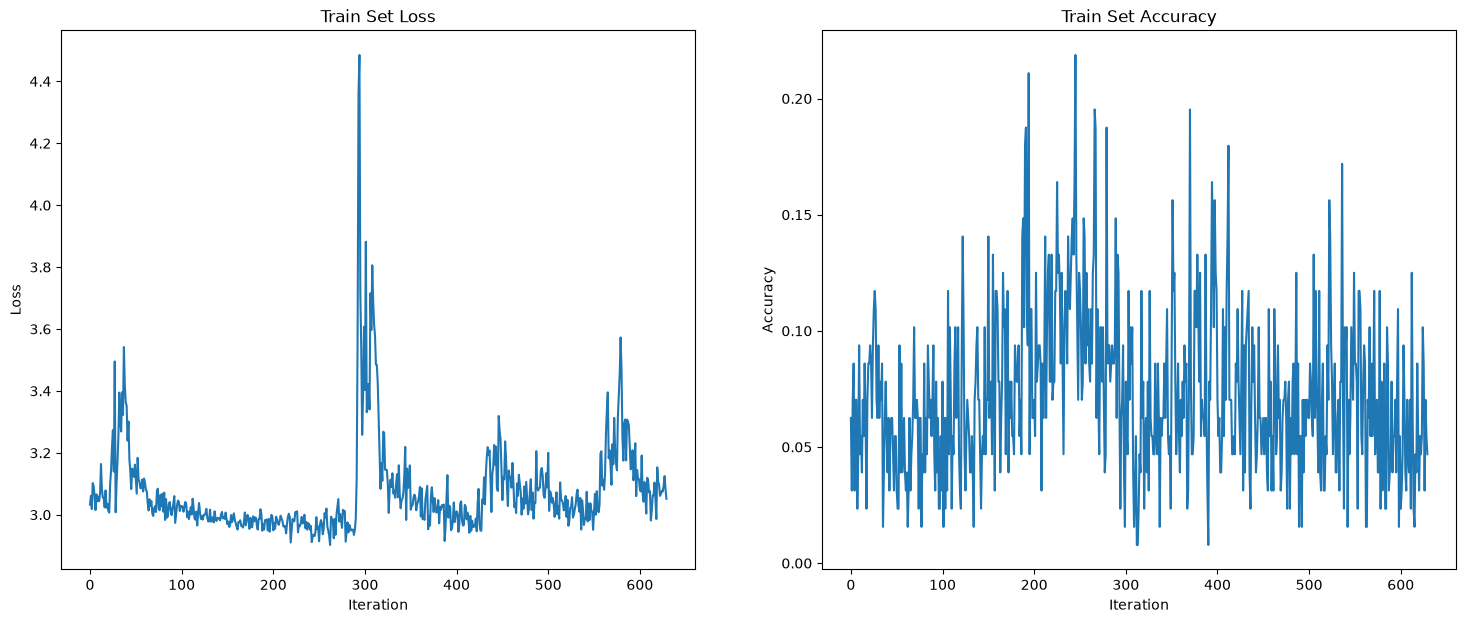

In [20]:
# Synaptic decay heterogeneity

import torch
from torch import Tensor
import torch.nn as nn
import snntorch as snn
from snntorch import utils
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

def sample_heterogeneous_decays(n_neurons: int) -> Tensor:
    upper_bound = 0.96
    lower_bound = 0.69
    decay_range = upper_bound - lower_bound
    return torch.rand(n_neurons, dtype=torch.float, device=device) * decay_range + lower_bound

class SimpleSRNNHeterogeneousDecay(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out))
            beta_layer = sample_heterogeneous_decays(_n_out)
            modules.append(snn.RLeaky(beta=beta_layer, linear_features=_n_out, init_hidden=True, learn_beta=False))

        modules.append(nn.Linear(ns_hidden[-1], n_out))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, data: Tensor) -> tuple[Tensor, Tensor]:
        spk_rec, mem_rec = [], []
        utils.reset(self.net)

        for step in range(data.size(0)):
            spk_out, mem_out = self.net(data[step])
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNHeterogeneousDecay(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.08409926470588236


Epoch 0:   2%|▏         | 1/63 [00:00<00:35,  1.77it/s, acc=4.69%, loss=3.02]

Epoch 0, Iteration 0 — Loss: 3.02, Acc: 4.69%


Epoch 0:  41%|████▏     | 26/63 [00:15<00:21,  1.69it/s, acc=3.12%, loss=3.11] 

Epoch 0, Iteration 25 — Loss: 3.11, Acc: 3.12%


...

Epoch 9, Iteration 25 — Loss: 3.03, Acc: 7.81%


Epoch 9:  81%|████████  | 51/63 [00:37<00:08,  1.43it/s, acc=10.94%, loss=3.04]

Epoch 9, Iteration 50 — Loss: 3.04, Acc: 10.94%


Epoch 9: 100%|██████████| 63/63 [00:46<00:00,  1.36it/s, acc=4.69%, loss=3.01] 


Test Accuracy after training is: 0.05560661764705882


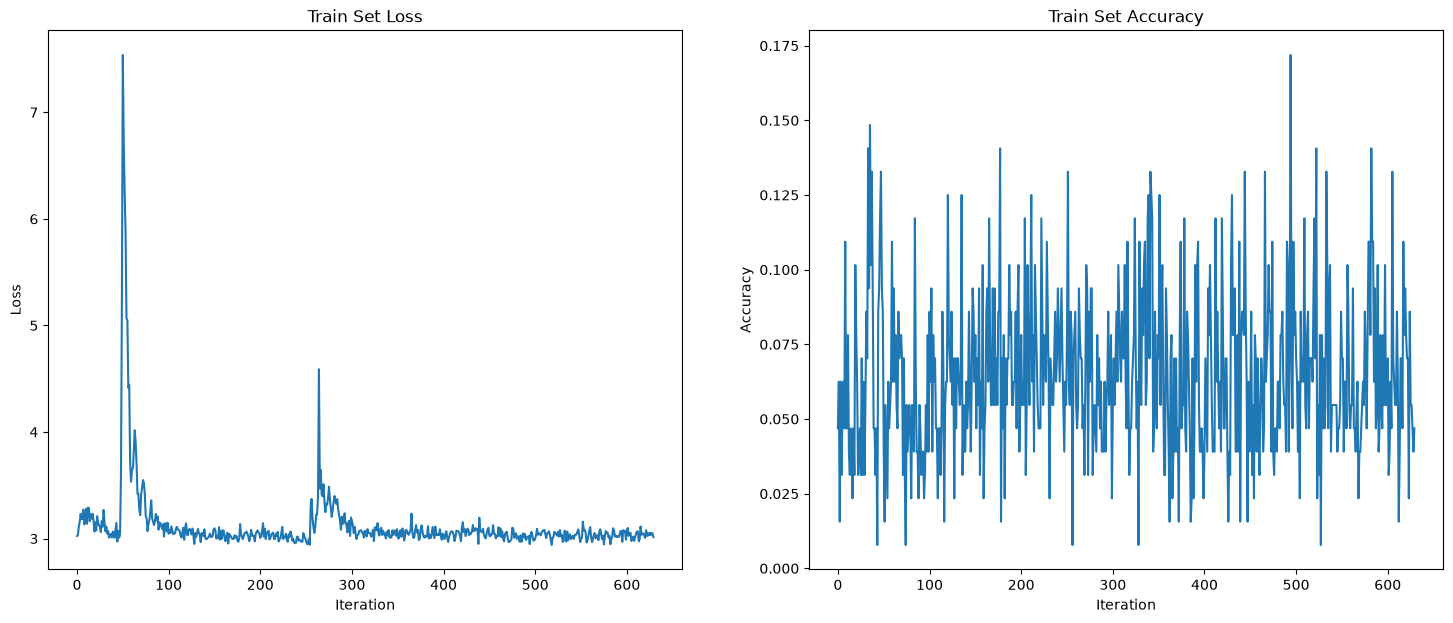

In [14]:
# Learnable decays

import torch
from torch import Tensor
import torch.nn as nn
import snntorch as snn
from snntorch import utils
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

class SimpleSRNNAdaptiveDecay(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out))
            modules.append(snn.RLeaky(beta=beta, linear_features=_n_out, init_hidden=True, learn_beta=True))

        modules.append(nn.Linear(ns_hidden[-1], n_out))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, data: Tensor) -> tuple[Tensor, Tensor]:
        spk_rec, mem_rec = [], []
        utils.reset(self.net)

        for step in range(data.size(0)):
            spk_out, mem_out = self.net(data[step])
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNAdaptiveDecay(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.034466911764705885


Epoch 0:   2%|▏         | 1/63 [00:00<00:39,  1.56it/s, acc=7.81%, loss=3.08]

Epoch 0, Iteration 0 — Loss: 3.08, Acc: 7.81%


Epoch 0:  41%|████▏     | 26/63 [00:17<00:26,  1.39it/s, acc=5.47%, loss=3.18] 

Epoch 0, Iteration 25 — Loss: 3.18, Acc: 5.47%


...

Epoch 9, Iteration 25 — Loss: 3.01, Acc: 10.94%


Epoch 9:  81%|████████  | 51/63 [00:32<00:07,  1.67it/s, acc=7.03%, loss=3.10] 

Epoch 9, Iteration 50 — Loss: 3.10, Acc: 7.03%


Epoch 9: 100%|██████████| 63/63 [00:40<00:00,  1.57it/s, acc=6.25%, loss=3.10] 


Test Accuracy after training is: 0.04917279411764706


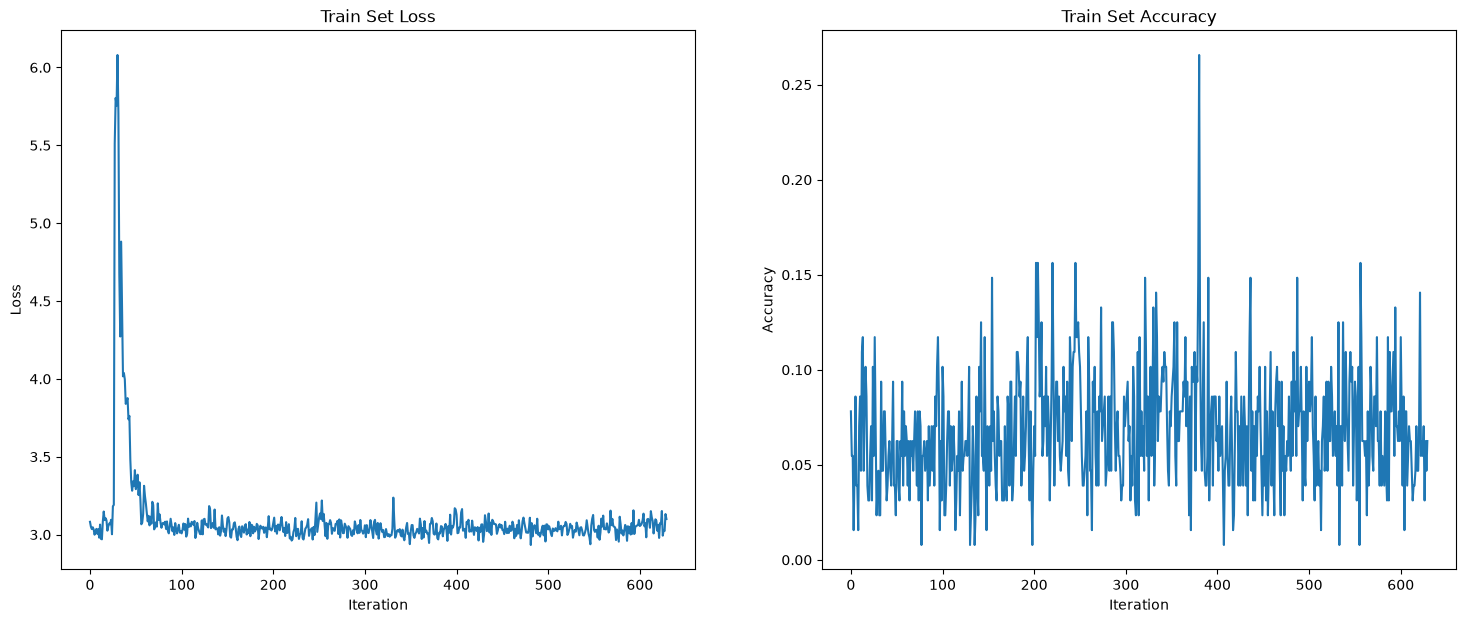

In [19]:
# Synaptic decay heterogeneity + learnable decays

import torch
from torch import Tensor
import torch.nn as nn
import snntorch as snn
from snntorch import utils
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

def sample_heterogeneous_decays(n_neurons: int) -> Tensor:
    upper_bound = 0.96
    lower_bound = 0.69
    decay_range = upper_bound - lower_bound
    return torch.rand(n_neurons, dtype=torch.float, device=device) * decay_range + lower_bound

class SimpleSRNNHeterogeneousAdaptiveDecay(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out))
            beta_layer = sample_heterogeneous_decays(_n_out)
            modules.append(snn.RLeaky(beta=beta_layer, linear_features=_n_out, init_hidden=True, learn_beta=True))

        modules.append(nn.Linear(ns_hidden[-1], n_out))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, data: Tensor) -> tuple[Tensor, Tensor]:
        spk_rec, mem_rec = [], []
        utils.reset(self.net)

        for step in range(data.size(0)):
            spk_out, mem_out = self.net(data[step])
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNHeterogeneousAdaptiveDecay(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.042738970588235295


Epoch 0:   2%|▏         | 1/63 [00:00<00:28,  2.21it/s, acc=6.25%, loss=3.16]

Epoch 0, Iteration 0 — Loss: 3.16, Acc: 6.25%


Epoch 0:  41%|████▏     | 26/63 [00:10<00:14,  2.48it/s, acc=5.47%, loss=3.29]

Epoch 0, Iteration 25 — Loss: 3.29, Acc: 5.47%


...

Epoch 9, Iteration 25 — Loss: 2.94, Acc: 14.06%


Epoch 9:  81%|████████  | 51/63 [00:23<00:05,  2.04it/s, acc=8.59%, loss=2.93] 

Epoch 9, Iteration 50 — Loss: 2.93, Acc: 8.59%


Epoch 9: 100%|██████████| 63/63 [00:30<00:00,  2.10it/s, acc=10.94%, loss=2.92]


Test Accuracy after training is: 0.0859375


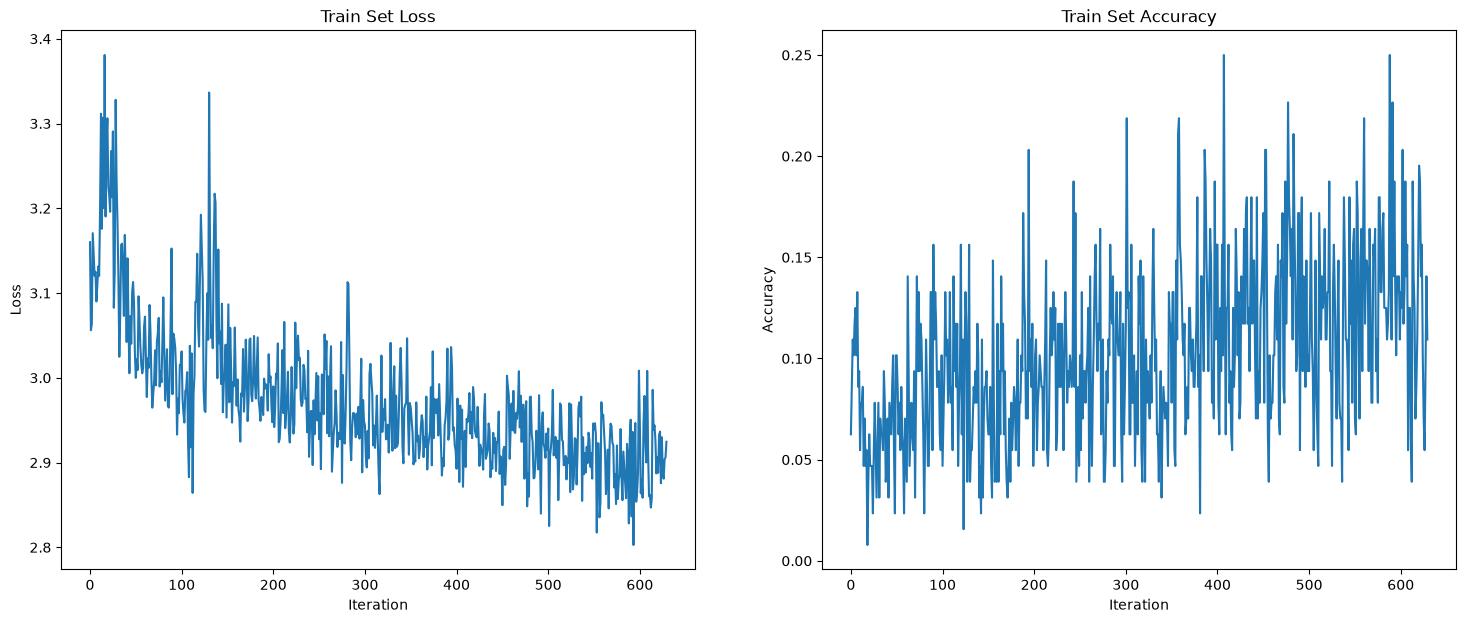

In [ ]:
# Only one hidden layer

import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = models.SimpleSRNN(
    n_in=input_dim,
    ns_hidden=[256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.04733455882352941


Epoch 0:   2%|▏         | 1/63 [00:00<00:26,  2.31it/s, acc=3.91%, loss=3.10]

Epoch 0, Iteration 0 — Loss: 3.10, Acc: 3.91%


Epoch 0:  41%|████▏     | 26/63 [00:13<00:24,  1.52it/s, acc=7.03%, loss=3.00] 

Epoch 0, Iteration 25 — Loss: 3.00, Acc: 7.03%


...

Epoch 9, Iteration 25 — Loss: 2.82, Acc: 14.06%


Epoch 9:  81%|████████  | 51/63 [00:38<00:09,  1.32it/s, acc=17.97%, loss=2.86]

Epoch 9, Iteration 50 — Loss: 2.86, Acc: 17.97%


Epoch 9: 100%|██████████| 63/63 [00:46<00:00,  1.35it/s, acc=21.09%, loss=2.87]


Test Accuracy after training is: 0.24310661764705882


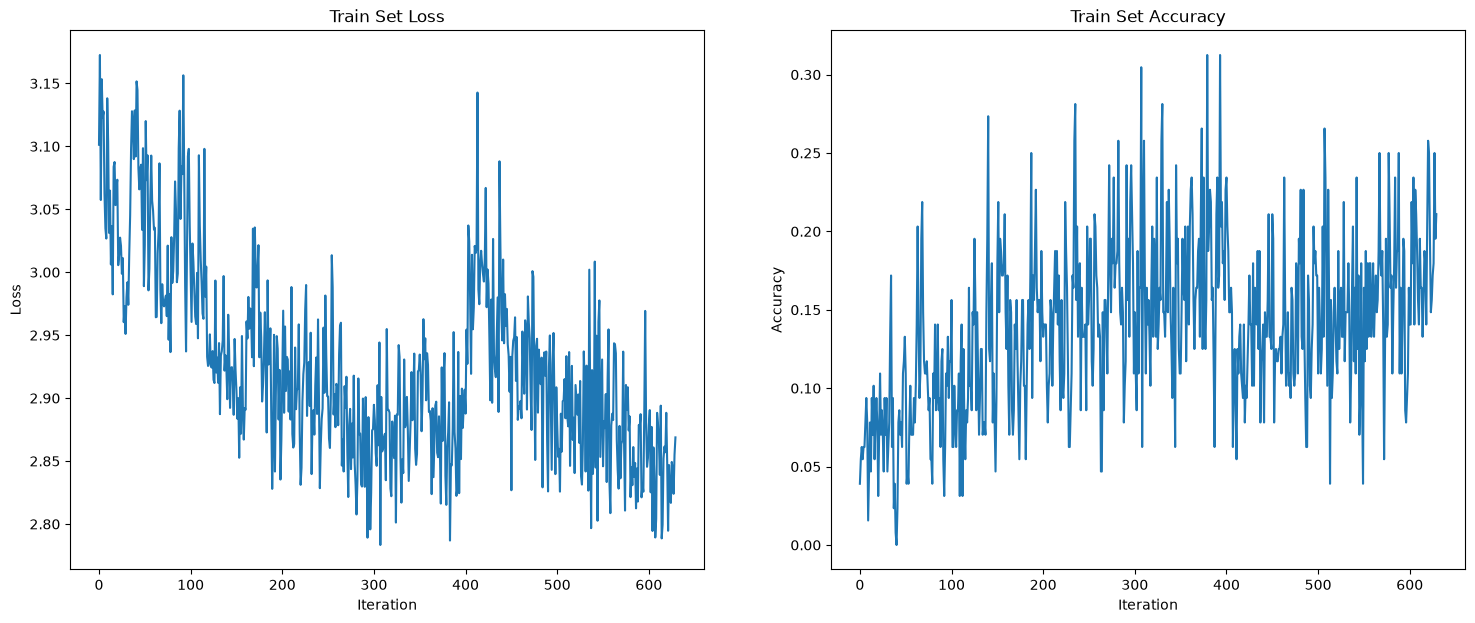

In [ ]:
# Synaptic decay heterogeneity + learnable decays + small model

import torch
from torch import Tensor
import torch.nn as nn
import snntorch as snn
from snntorch import utils
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

def sample_heterogeneous_decays(n_neurons: int) -> Tensor:
    upper_bound = 0.96
    lower_bound = 0.69
    decay_range = upper_bound - lower_bound
    return torch.rand(n_neurons, dtype=torch.float, device=device) * decay_range + lower_bound

class SimpleSRNNHeterogeneousAdaptiveDecay(nn.Module):
    def __init__(self, n_in: int, ns_hidden: list[int], n_out: int, beta: float) -> None:
        super().__init__()
        layers = [n_in] + ns_hidden
        modules = [nn.Flatten()]

        for _n_in, _n_out in zip(layers[:-1], layers[1:]):
            modules.append(nn.Linear(_n_in, _n_out))
            beta_layer = sample_heterogeneous_decays(_n_out)
            modules.append(snn.RLeaky(beta=beta_layer, linear_features=_n_out, init_hidden=True, learn_beta=True))

        modules.append(nn.Linear(ns_hidden[-1], n_out))
        modules.append(snn.Leaky(beta=beta, init_hidden=True, output=True, reset_mechanism='none'))
        self.net = nn.Sequential(*modules)

    def forward(self, data: Tensor) -> tuple[Tensor, Tensor]:
        spk_rec, mem_rec = [], []
        utils.reset(self.net)

        for step in range(data.size(0)):
            spk_out, mem_out = self.net(data[step])
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = SimpleSRNNHeterogeneousAdaptiveDecay(
    n_in=input_dim,
    ns_hidden=[256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")